In [29]:
!pip install givernylocal


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Nitipon\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [30]:
import numpy as np
import matplotlib.pyplot as plt

from givernylocal.turbulence_dataset import turb_dataset
from givernylocal.turbulence_toolkit import getCutout

In [31]:
cube = turb_dataset(
    dataset_title="isotropic1024coarse",
    output_path="./jhtdb_output",
    auth_token="edu.gatech.jerrychen-6b7455a7"
)

In [32]:
high_res_size = 128

axes_ranges = np.array([
    [1, high_res_size],   # x
    [1, high_res_size],   # y
    [1, high_res_size],   # z
    [1, 1]                # time
])

strides = np.array([1,1,1,1])

cutout = getCutout(
    cube,
    var="velocity",
    xyzt_axes_ranges_original=axes_ranges,
    xyzt_strides=strides
)


-----
getCutout is processing...

total time elapsed = 21.081 seconds (0.351 minutes)

query completed successfully.
-----


In [33]:
print(cutout)

<xarray.Dataset> Size: 25MB
Dimensions:        (zcoor: 128, ycoor: 128, xcoor: 128, values: 3)
Coordinates:
  * zcoor          (zcoor) float64 1kB 0.0 0.006136 0.01227 ... 0.7731 0.7793
  * ycoor          (ycoor) float64 1kB 0.0 0.006136 0.01227 ... 0.7731 0.7793
  * xcoor          (xcoor) float64 1kB 0.0 0.006136 0.01227 ... 0.7731 0.7793
Dimensions without coordinates: values
Data variables:
    velocity_0001  (zcoor, ycoor, xcoor, values) float32 25MB -0.6635 ... -0....
Attributes: (12/14)
    dataset:      isotropic1024coarse
    t_start:      1
    t_end:        1
    t_step:       1
    x_start:      1
    y_start:      1
    ...           ...
    y_end:        128
    z_end:        128
    x_step:       1
    y_step:       1
    z_step:       1
    filterWidth:  1


In [34]:
velocity = cutout["velocity_0001"].values

print(velocity.shape)

(128, 128, 128, 3)


In [35]:
speed = np.sqrt(
    velocity[:,:,:,0]**2 +
    velocity[:,:,:,1]**2 +
    velocity[:,:,:,2]**2
)

print(speed.shape)

(128, 128, 128)


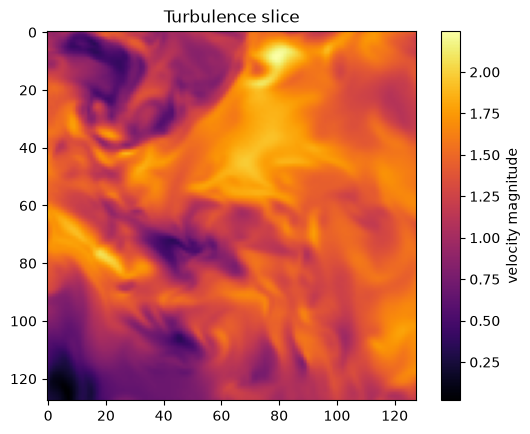

In [36]:
plt.imshow(speed[:,:,8], cmap="inferno")
plt.colorbar(label="velocity magnitude")
plt.title("Turbulence slice")
plt.show()

C:\Users\Nitipon\AppData\Local\Temp\ipykernel_7972\1590596030.py:20: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


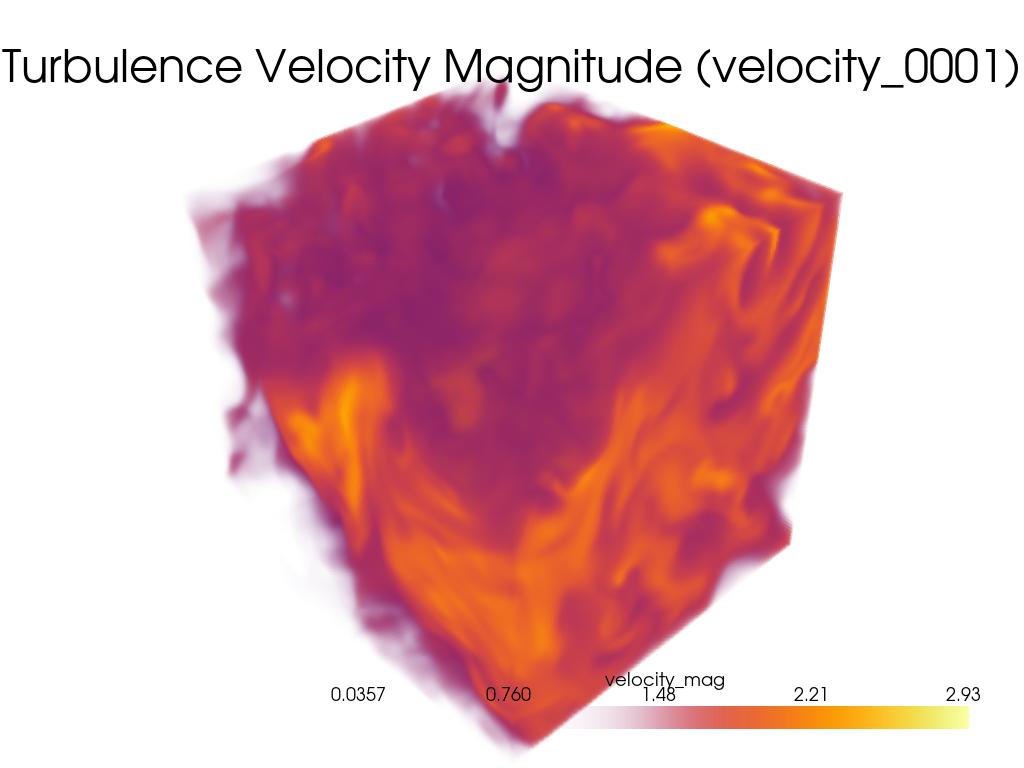

In [37]:
import pyvista as pv

grid = pv.ImageData()

grid.dimensions = np.array(speed.shape) + 1
grid.spacing = (1,1,1)
grid.origin = (0,0,0)

grid.cell_data["velocity_mag"] = speed.flatten(order="F")

plotter = pv.Plotter()

plotter.add_volume(
    grid,
    cmap="inferno",
    opacity="sigmoid"
)

plotter.add_title("Turbulence Velocity Magnitude (velocity_0001)")
plotter.show()

Filtered shape (128^3): (128, 128, 128)
Downsampled shape (32^3): (32, 32, 32)


C:\Users\Nitipon\AppData\Local\Temp\ipykernel_7972\1505133402.py:41: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


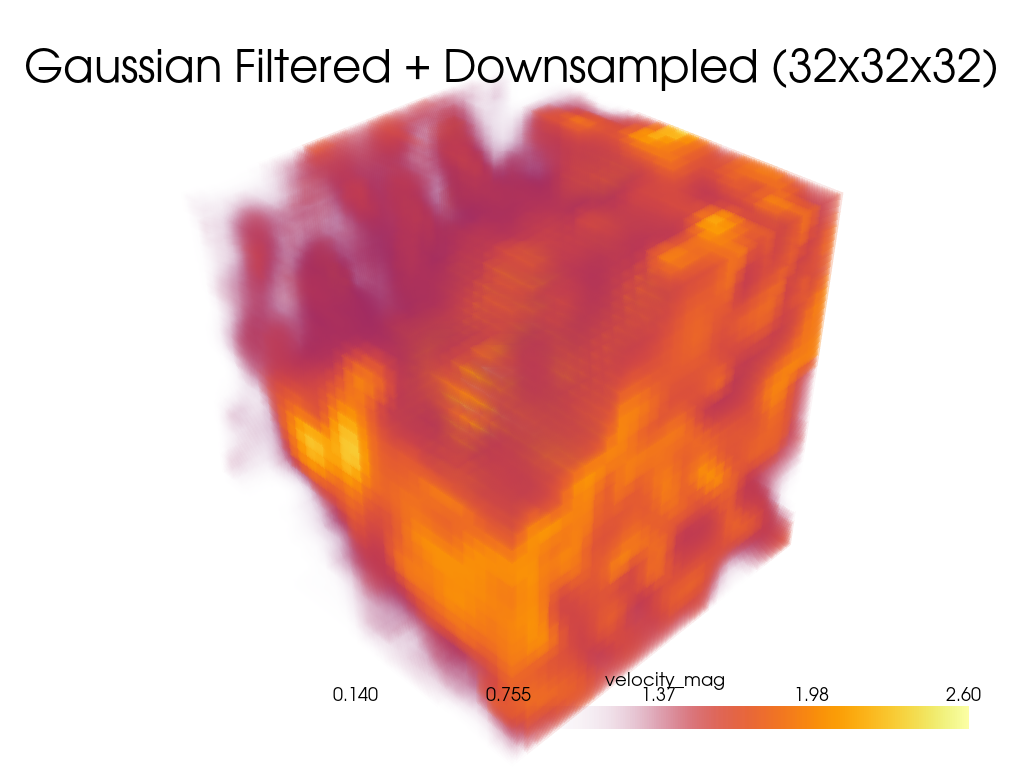

In [38]:
from scipy.ndimage import gaussian_filter

# ---- 1. Gaussian filter ----
sigma = 1.0   # smoothing strength

speed_filtered = gaussian_filter(speed, sigma=sigma)

print(f"Filtered shape ({high_res_size}^3):", speed_filtered.shape)


# ---- 2. Downsample (high-res -> low-res) ----
downsample_factor = 4
low_res_size = high_res_size // downsample_factor

if high_res_size % downsample_factor != 0:
    raise ValueError("high_res_size must be divisible by downsample_factor")

speed_down = speed_filtered[::downsample_factor, ::downsample_factor, ::downsample_factor]

print(f"Downsampled shape ({low_res_size}^3):", speed_down.shape)


# ---- 3. Visualize coarse volume ----
grid2 = pv.ImageData()

grid2.dimensions = np.array(speed_down.shape) + 1
grid2.spacing = (1,1,1)
grid2.origin = (0,0,0)

grid2.cell_data["velocity_mag"] = speed_down.flatten(order="F")

plotter = pv.Plotter()

plotter.add_volume(
    grid2,
    cmap="inferno",
    opacity="sigmoid"
)

plotter.add_title(f"Gaussian Filtered + Downsampled ({low_res_size}x{low_res_size}x{low_res_size})")
plotter.show()